In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [19]:
#Load Dataset
df=pd.read_csv("C:/Users/SANTOSH\Downloads/student_performance_dataset (1).csv")
df.head()


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [20]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


Clean and Preprocess Data

In [33]:
# Create binary classification column (Pass = 1 if final_exam_score >= 60, else Fail = 0)
df["pass_fail"] = (df["final_exam_score"] >= 60).astype(int)

df["parental_education"] = df["parental_education"].fillna("Unknown")

categorical_cols = [
    "gender",
    "parental_education",
    "internet_access",
    "extracurricular_activities",
    "part_time_job",
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Data Cleaning Complete. Shape of encoded dataset:", df_encoded.shape)

Data Cleaning Complete. Shape of encoded dataset: (1000, 16)


Exploratory Data Analysis (EDA)

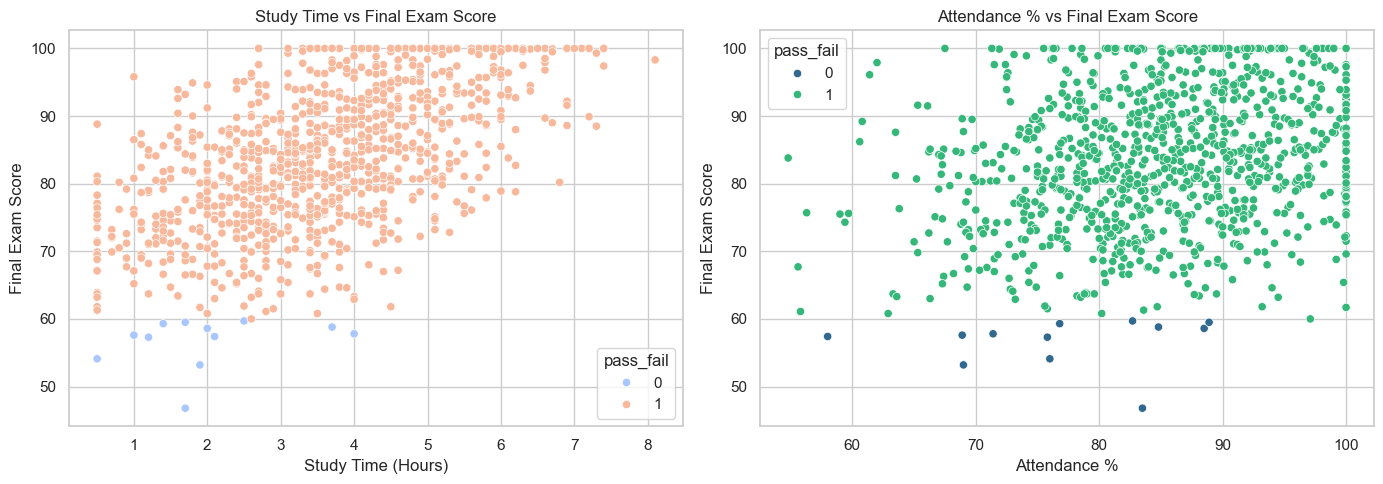

Correlation Matrix:


,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
study_time_hours,1.000000,-0.043712,0.005594,-0.035700,0.567513
attendance_percent,-0.043712,1.000000,0.034089,-0.014310,0.261872
sleep_hours,0.005594,0.034089,1.000000,0.000943,0.147811
previous_grade,-0.035700,-0.014310,0.000943,1.000000,0.406327
final_exam_score,0.567513,0.261872,0.147811,0.406327,1.000000


In [34]:
# Create EDA Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. Study Time vs Final Exam Score
sns.scatterplot(
    data=df,
    x="study_time_hours",
    y="final_exam_score",
    hue="pass_fail",
    palette="coolwarm",
    ax=axes[0],
)
axes[0].set_title("Study Time vs Final Exam Score")
axes[0].set_xlabel("Study Time (Hours)")
axes[0].set_ylabel("Final Exam Score")

# 2. Attendance % vs Final Exam Score
sns.scatterplot(
    data=df,
    x="attendance_percent",
    y="final_exam_score",
    hue="pass_fail",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Attendance % vs Final Exam Score")
axes[1].set_xlabel("Attendance %")
axes[1].set_ylabel("Final Exam Score")

plt.tight_layout()
plt.show()
# Display Correlations with target
numerical_cols = [
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "previous_grade",
    "final_exam_score",
]
print("Correlation Matrix:")
display(df[numerical_cols].corr())


Define Features, Train-Test Split & Feature Scaling

In [35]:
# Import sklearn utilities needed for splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define feature variables (X) and target variables (y)
# Use only two features
feature_cols = [
    "study_time_hours",
    "previous_grade"
]

X = df_encoded[feature_cols]

y_classification = df_encoded["pass_fail"]

X = df_encoded[feature_cols]
y_regression = df_encoded['final_exam_score']  # Target for Linear Regression
y_classification = df_encoded['pass_fail']     # Target for Logistic Regression

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_regression, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Data successfully split and scaled!")

Data successfully split and scaled!


Linear Regression (Score Estimation)

In [36]:
# Import sklearn modules needed for Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)

# Predictions
y_pred_r = lin_reg.predict(X_test_r_scaled)

# Evaluation
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("--- Linear Regression Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

--- Linear Regression Performance ---
R² Score: 0.5075
Mean Squared Error (MSE): 53.0139


Logistic Regression (Pass/Fail Classification)

In [39]:
# Import sklearn modules needed for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train_c_scaled, y_train_c)

# Predictions
y_pred_c = log_reg.predict(X_test_c_scaled)

# Evaluation
accuracy = accuracy_score(y_test_c, y_pred_c)

print("--- Logistic Regression Performance ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))



--- Logistic Regression Performance ---
Model Accuracy: 99.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      1.00      0.99       198

    accuracy                           0.99       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.98      0.99      0.99       200



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


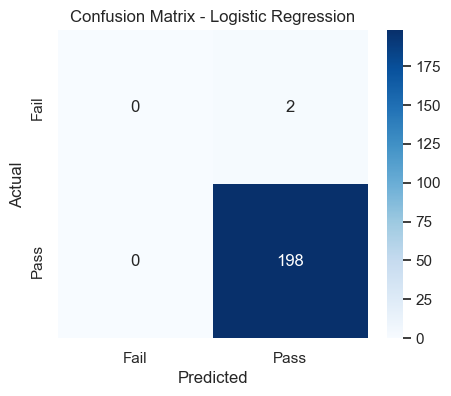

In [38]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Output Demonstration — Predict for a Sample Student

In [40]:
# Make a prediction on a sample student from the test set
sample_student = X_test_c.iloc[[0]]
sample_scaled = scaler.transform(sample_student)

pred_score = lin_reg.predict(sample_scaled)[0]
pred_status = log_reg.predict(sample_scaled)[0]

print("--- Prediction Output ---")
print(f"Predicted Final Exam Score: {pred_score:.2f} / 100")
print(f"Predicted Result Status: {'PASS' if pred_status == 1 else 'FAIL'}")

--- Prediction Output ---
Predicted Final Exam Score: 89.72 / 100
Predicted Result Status: PASS


In [41]:
import joblib

joblib.dump(lin_reg, "linear_model.pkl")
joblib.dump(log_reg, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully!")

All models saved successfully!


In [24]:
import os
print(os.getcwd())

C:\Users\SANTOSH


In [42]:
import joblib

joblib.dump(lin_reg, r"C:\Users\SANTOSH\OneDrive\Desktop\StudentPrediction\linear_model.pkl")
joblib.dump(log_reg, r"C:\Users\SANTOSH\OneDrive\Desktop\StudentPrediction\model.pkl")
joblib.dump(scaler, r"C:\Users\SANTOSH\OneDrive\Desktop\StudentPrediction\scaler.pkl")

print("All files saved in StudentPrediction folder")

All files saved in StudentPrediction folder
